In [35]:
import pandas as pd

df = pd.read_csv("/content/developer_productivity.csv")

df.head()

,developer_id,commits_per_week,lines_added,lines_deleted,files_changed,bugs_reported,code_review_comments,avg_review_time_hours,test_coverage_percent,deployment_frequency,late_night_commits,commit_risk
0,dev_07,8,89,54,1,3,0,4.5,67.0,2,1,Medium
1,dev_20,4,80,100,4,1,4,21.0,78.3,1,0,Medium
2,dev_08,9,18,9,9,0,4,4.9,79.9,3,0,Low
3,dev_15,3,33,107,4,0,1,15.9,82.5,2,3,Medium
4,dev_07,3,36,15,5,0,2,1.8,87.3,1,1,Low


In [36]:
df.columns

Index(['developer_id', 'commits_per_week', 'lines_added', 'lines_deleted',
       'files_changed', 'bugs_reported', 'code_review_comments',
       'avg_review_time_hours', 'test_coverage_percent',
       'deployment_frequency', 'late_night_commits', 'commit_risk'],
      dtype='object')

In [37]:
X = df.drop("developer_id", axis=1)
y = df["developer_id"]

print(X.shape)
print(y.shape)

(2000, 11)
(2000,)


In [38]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(2000, 12)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 12)
(400, 12)


In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.05


In [42]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [43]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.05


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [45]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.055


In [46]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [47]:
from sklearn.metrics import accuracy_score

y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.035


In [48]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.655125,
        0.571975,
        0.649450,
        0.658075
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.655125
1,Decision Tree,0.571975
2,Random Forest,0.649450
3,Gradient Boosting,0.658075


In [49]:
comparison_df.to_csv("model_comparison.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully


In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, y_pred in models.items():
    results.append([
        model_name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

comparison_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.050,0.041010,0.050,0.040616
1,Decision Tree,0.050,0.050988,0.050,0.049501
2,Random Forest,0.055,0.059934,0.055,0.055550
3,Gradient Boosting,0.035,0.036648,0.035,0.035002


In [51]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Updated CSV saved")

Updated CSV saved


In [52]:
models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])

In [53]:
print(models["Logistic Regression"])

['dev_20' 'dev_16' 'dev_15' 'dev_02' 'dev_09' 'dev_15' 'dev_09' 'dev_07'
 'dev_14' 'dev_14' 'dev_09' 'dev_12' 'dev_17' 'dev_06' 'dev_12' 'dev_07'
 'dev_02' 'dev_12' 'dev_09' 'dev_09' 'dev_14' 'dev_08' 'dev_07' 'dev_09'
 'dev_15' 'dev_18' 'dev_18' 'dev_20' 'dev_07' 'dev_16' 'dev_04' 'dev_20'
 'dev_04' 'dev_15' 'dev_17' 'dev_14' 'dev_07' 'dev_12' 'dev_07' 'dev_18'
 'dev_03' 'dev_15' 'dev_03' 'dev_02' 'dev_14' 'dev_18' 'dev_18' 'dev_14'
 'dev_09' 'dev_09' 'dev_02' 'dev_02' 'dev_09' 'dev_12' 'dev_18' 'dev_07'
 'dev_19' 'dev_14' 'dev_04' 'dev_14' 'dev_12' 'dev_09' 'dev_20' 'dev_04'
 'dev_09' 'dev_04' 'dev_10' 'dev_03' 'dev_18' 'dev_09' 'dev_14' 'dev_08'
 'dev_10' 'dev_11' 'dev_12' 'dev_09' 'dev_02' 'dev_02' 'dev_15' 'dev_02'
 'dev_04' 'dev_09' 'dev_04' 'dev_12' 'dev_07' 'dev_14' 'dev_15' 'dev_18'
 'dev_09' 'dev_12' 'dev_15' 'dev_13' 'dev_09' 'dev_17' 'dev_20' 'dev_12'
 'dev_13' 'dev_09' 'dev_07' 'dev_13' 'dev_07' 'dev_20' 'dev_20' 'dev_15'
 'dev_01' 'dev_09' 'dev_09' 'dev_12' 'dev_12' 'dev_

In [54]:
type(models["Logistic Regression"])


numpy.ndarray

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["Logistic Regression"]))

              precision    recall  f1-score   support

      dev_01       0.00      0.00      0.00        19
      dev_02       0.00      0.00      0.00        23
      dev_03       0.00      0.00      0.00        13
      dev_04       0.06      0.08      0.07        25
      dev_05       0.00      0.00      0.00        17
      dev_06       0.00      0.00      0.00        24
      dev_07       0.08      0.19      0.11        16
      dev_08       0.00      0.00      0.00        15
      dev_09       0.04      0.12      0.06        16
      dev_10       0.15      0.07      0.09        30
      dev_11       0.00      0.00      0.00        19
      dev_12       0.06      0.14      0.08        22
      dev_13       0.06      0.07      0.06        15
      dev_14       0.10      0.19      0.13        16
      dev_15       0.00      0.00      0.00        28
      dev_16       0.00      0.00      0.00        21
      dev_17       0.00      0.00      0.00        16
      dev_18       0.08    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


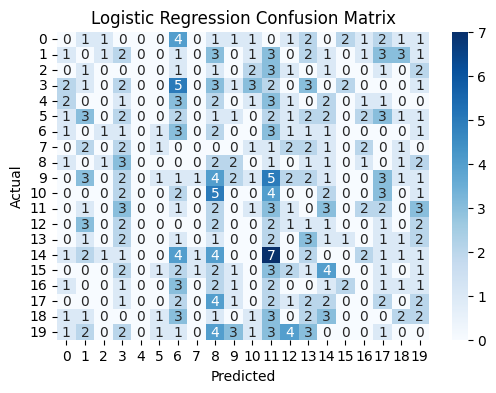

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

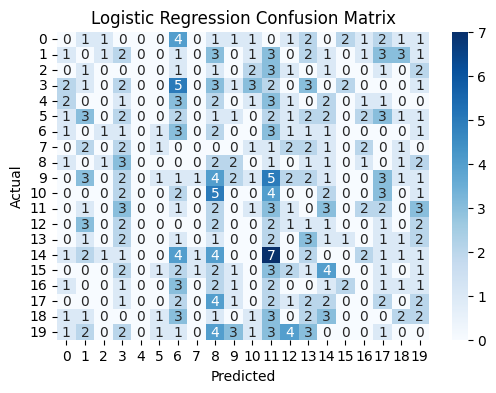

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [58]:
models

{'Logistic Regression': array(['dev_20', 'dev_16', 'dev_15', 'dev_02', 'dev_09', 'dev_15',
        'dev_09', 'dev_07', 'dev_14', 'dev_14', 'dev_09', 'dev_12',
        'dev_17', 'dev_06', 'dev_12', 'dev_07', 'dev_02', 'dev_12',
        'dev_09', 'dev_09', 'dev_14', 'dev_08', 'dev_07', 'dev_09',
        'dev_15', 'dev_18', 'dev_18', 'dev_20', 'dev_07', 'dev_16',
        'dev_04', 'dev_20', 'dev_04', 'dev_15', 'dev_17', 'dev_14',
        'dev_07', 'dev_12', 'dev_07', 'dev_18', 'dev_03', 'dev_15',
        'dev_03', 'dev_02', 'dev_14', 'dev_18', 'dev_18', 'dev_14',
        'dev_09', 'dev_09', 'dev_02', 'dev_02', 'dev_09', 'dev_12',
        'dev_18', 'dev_07', 'dev_19', 'dev_14', 'dev_04', 'dev_14',
        'dev_12', 'dev_09', 'dev_20', 'dev_04', 'dev_09', 'dev_04',
        'dev_10', 'dev_03', 'dev_18', 'dev_09', 'dev_14', 'dev_08',
        'dev_10', 'dev_11', 'dev_12', 'dev_09', 'dev_02', 'dev_02',
        'dev_15', 'dev_02', 'dev_04', 'dev_09', 'dev_04', 'dev_12',
        'dev_07', 'dev_14

In [59]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                            DataFrame                           commits_per_week  l<...>n[2000 rows x 12 columns]
X_test                       DataFrame                           commits_per_week  l<...>\n[400 rows x 12 columns]
X_train                      DataFrame                           commits_per_week  l<...>n[1600 rows x 12 columns]
accuracy                     float                       

In [60]:
lr = LogisticRegression(max_iter=1000)

In [61]:
import joblib

joblib.dump(lr, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [62]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [63]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

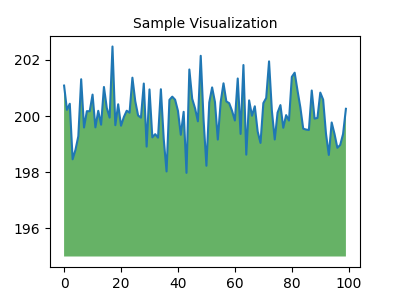

In [64]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)